<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy 
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ? 
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [78]:
#Importation de la librairie Pandas
import pandas as pd

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [81]:
# Charger le fichier population.csv
population = pd.read_csv('population.csv')

# Charger le fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

# Charger le fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

# Charger le fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [85]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [87]:
#Consulter le nombre de colonnes
nombre_de_colonnes = population.shape[1]
print(f"Le fichier contient {nombre_de_colonnes} colonnes.")

#La nature des données dans chacune des colonnes
print(population.dtypes)

#Le nombre de valeurs présentes dans chacune des colonnes
print(population.count())


Le fichier contient 3 colonnes.
Zone       object
Année       int64
Valeur    float64
dtype: object
Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [89]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [91]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000

population['Valeur'] = population['Valeur'] * 1000

In [93]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur': 'Population'}, inplace=True)

In [95]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [98]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [100]:
#Consulter le nombre de colonnes
nombre_de_colonnes = dispo_alimentaire.shape[1]
print(f"Le fichier contient {nombre_de_colonnes} colonnes.")

Le fichier contient 18 colonnes.


In [102]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [104]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0, inplace=True)

In [106]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
colonnes_a_convertir = ['Aliments pour animaux', 'Autres Utilisations', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 
                        'Nourriture', 'Pertes', 'Production', 'Semences', 'Traitement', 'Variation de stock']

dispo_alimentaire[colonnes_a_convertir] = dispo_alimentaire[colonnes_a_convertir] * 1000000

In [108]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [111]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [113]:
#Consulter le nombre de colonnes
nombre_de_colonnes = aide_alimentaire.shape[1]
print(f"Le fichier contient {nombre_de_colonnes} colonnes.")

Le fichier contient 4 colonnes.


In [115]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [117]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire': 'Zone'}, inplace=True)

In [119]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] = aide_alimentaire['Valeur'] * 1000

In [121]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [124]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [126]:
#Consulter le nombre de colonnes
nombre_de_colonnes = sous_nutrition.shape[1]
print(f"Le fichier contient {nombre_de_colonnes} colonnes.")

Le fichier contient 3 colonnes.


In [128]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [130]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])

ValueError: Unable to parse string "<0.1" at position 60

In [132]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')

#Puis remplacement des NaN en 0
sous_nutrition['Valeur'] = sous_nutrition['Valeur'].fillna(0)

In [134]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition.rename(columns={'Valeur': 'sous_nutrition'}, inplace=True)

In [136]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition'] = sous_nutrition['sous_nutrition'] * 1000000

In [138]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [141]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017

# Filtrer les données pour l'année 2017 dans la table population
population_2017 = population[population["Année"]==2017]

# Filtrer les données pour l'intervalle 2016-2018 dans la table sous_nutrition
sous_nutrition_2017 = sous_nutrition[sous_nutrition["Année"]=="2016-2018"]

# Fusionner les deux tables en se basant sur la colonne "Zone"
population_sous_nutrition = pd.merge(population_2017, sous_nutrition_2017, on=["Zone"])

# Afficher les 5 premières lignes pour vérifier
population_sous_nutrition.head()

,Zone,Année_x,Population,Année_y,sous_nutrition
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0
2,Albanie,2017,2884169.0,2016-2018,100000.0
3,Algérie,2017,41389189.0,2016-2018,1300000.0
4,Allemagne,2017,82658409.0,2016-2018,0.0


In [143]:
#Affichage du dataset
population_sous_nutrition

,Zone,Année_x,Population,Année_y,sous_nutrition
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0
2,Albanie,2017,2884169.0,2016-2018,100000.0
3,Algérie,2017,41389189.0,2016-2018,1300000.0
4,Allemagne,2017,82658409.0,2016-2018,0.0
...,...,...,...,...,...
198,Venezuela (République bolivarienne du),2017,29402484.0,2016-2018,8000000.0
199,Viet Nam,2017,94600648.0,2016-2018,6500000.0
200,Yémen,2017,27834819.0,2016-2018,0.0
201,Zambie,2017,16853599.0,2016-2018,0.0


In [145]:
#Calcul et affichage du nombre de personnes en état de sous nutrition

# Calculer le nombre total de personnes en état de sous-nutrition
total_sous_nutrition = population_sous_nutrition['sous_nutrition'].sum()

#Total de la population dans le monde en 2017
total_population_2017 = population_sous_nutrition['Population'].sum()

#Pourcentage de la population en sous-nutrition
pourcentage_sous_nutrition = total_sous_nutrition/total_population_2017*100

# Afficher le résultat
print(f"Le nombre total de personnes en état de sous-nutrition en 2017 était de {int(total_sous_nutrition):,} soit {pourcentage_sous_nutrition:.2f} % de la population mondiale.")


Le nombre total de personnes en état de sous-nutrition en 2017 était de 535,700,000 soit 7.10 % de la population mondiale.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personnes qui pourraient être nourries</h3>
</div>

In [148]:
#Combien mange en moyenne un être humain ? 

# According to NHS UK, an average man needs 2,500kcal a day, an average woman needs 2,000kcal a day
#Source => https://www.nhs.uk/live-well/healthy-weight/managing-your-weight/understanding-calories/

besoin_calorique_journalier = 2000

In [150]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population

# Jointure des deux DataFrames
dispo_alimentaire_population = pd.merge(dispo_alimentaire, population_2017[['Zone', 'Population']], on="Zone")

# Affichage pour vérifier
dispo_alimentaire_population.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0


In [152]:
#Affichage du nouveau dataframe
dispo_alimentaire_population

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000000.0,0.0,0.0,3000000.0,0.0,2000000.0,0.0,0.0,0.0,636039.0
15412,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,636039.0
15413,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0
15414,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0


In [154]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement

# Création de la colonne 'dispo_kcal' (par jour) en multipliant les Kcal/personne/jour par la population
dispo_alimentaire_population['dispo_kcal'] = (
    dispo_alimentaire_population['Disponibilité alimentaire (Kcal/personne/jour)'] 
    * dispo_alimentaire_population['Population'] 
)

# calcul des kcal disponibles mondialement
total_dispo_kcal = dispo_alimentaire_population['dispo_kcal'].sum()
print(f"Le nombre total de kcal disponibles par jour en 2017 était de {int(total_dispo_kcal):,}.")

# Afficher les premières lignes pour vérifier
dispo_alimentaire_population.head()

Le nombre total de kcal disponibles par jour en 2017 était de 20,918,984,627,331.


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,36296113.0,181480565.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,145184452.0


In [156]:
#Calcul du nombre d'humains pouvant être nourris
nombre_humains_nourris = total_dispo_kcal / besoin_calorique_journalier

# Afficher le résultat
print(f"Le nombre d'humains pouvant être nourris est estimé à {int(nombre_humains_nourris):,}.")

Le nombre d'humains pouvant être nourris est estimé à 10,459,492,313.


In [158]:
# Calcul de la population mondiale en 2017 (somme des populations dans le dataframe)
population_mondiale_2017 = population_2017['Population'].sum()
print(f"La population mondiale en 2017 était de {int(population_mondiale_2017):,} personnes.")

# Calcul du pourcentage de la population mondiale pouvant être nourrie
pourcentage_nourris = (nombre_humains_nourris / population_mondiale_2017) * 100
print(f"Le nombre théorique de personnes pouvant être nourries représente {pourcentage_nourris:.2f} % de la population mondiale en 2017.")

La population mondiale en 2017 était de 7,548,134,111 personnes.
Le nombre théorique de personnes pouvant être nourries représente 138.57 % de la population mondiale en 2017.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personnes qui pourraient être nourries avec les produits végétaux</h3>
</div>

In [161]:
#Transfert des données avec les végétaux dans un nouveau dataframe

# D'abord on va filtrer les données pour ne garder que les produits végétaux
dispo_vegetaux = dispo_alimentaire_population[dispo_alimentaire_population['Origine'] == 'vegetale']

# Afficher les 5 premières lignes pour vérifier
dispo_vegetaux.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,145184452.0
6,Afghanistan,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000000.0,0.0,3000000.0,3000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.0


In [163]:
# Calcul du nombre de kcal disponible pour les végétaux
total_kcal_vegetaux = dispo_vegetaux['dispo_kcal'].sum()

# Afficher le résultat
print(f"Le nombre total de Kcal disponibles pour les produits végétaux est de {int(total_kcal_vegetaux):,} Kcal.")

Le nombre total de Kcal disponibles pour les produits végétaux est de 17,260,764,211,501 Kcal.


In [165]:
# Calcul du nombre d'humains pouvant être nourris avec les végétaux
nombre_humains_nourris_vegetaux = total_kcal_vegetaux / besoin_calorique_journalier

# Afficher le résultat
print(f"Le nombre d'humains pouvant être nourris avec les végétaux est estimé à {int(nombre_humains_nourris_vegetaux):,}.")

Le nombre d'humains pouvant être nourris avec les végétaux est estimé à 8,630,382,105.


In [167]:
# Calcul du pourcentage de la population pouvant être nourrie avec les végétaux
pourcentage_nourris_vegetaux = (nombre_humains_nourris_vegetaux / population_mondiale_2017) * 100

# Afficher le pourcentage
print(f"Le pourcentage de la population mondiale pouvant être nourrie avec des végétaux est de {pourcentage_nourris_vegetaux:.2f} %.")

Le pourcentage de la population mondiale pouvant être nourrie avec des végétaux est de 114.34 %.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [170]:
#Calcul de la disponibilité totale
disponibilite_totale = dispo_alimentaire_population['Disponibilité intérieure'].sum()

# Affichage du résultat
print(f"La disponibilité totale est de {disponibilite_totale:,}")

La disponibilité totale est de 9,733,927,000,000.0


In [172]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures

# Liste des colonnes à parcourir pour calculer leur somme
colonnes_a_afficher = ['Aliments pour animaux', 'Pertes', 'Nourriture', 'Semences', 'Traitement','Production', 'Exportations - Quantité', 'Importations - Quantité', 'Variation de stock']

# Boucle pour afficher la somme de chaque colonne
for colonne in colonnes_a_afficher:
    # Calcul de la somme de chaque colonne
    total_colonne = dispo_alimentaire_population[colonne].sum()
    
    # Affichage du résultat
    print(f"La somme pour les {colonne} est de {int(total_colonne):,}.")


La somme pour les Aliments pour animaux est de 1,288,002,000,000.
La somme pour les Pertes est de 452,283,000,000.
La somme pour les Nourriture est de 4,805,525,000,000.
La somme pour les Semences est de 153,317,000,000.
La somme pour les Traitement est de 2,185,641,000,000.
La somme pour les Production est de 9,921,364,000,000.
La somme pour les Exportations - Quantité est de 1,331,999,000,000.
La somme pour les Importations - Quantité est de 1,247,345,000,000.
La somme pour les Variation de stock est de -102,605,000,000.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [175]:
#Création d'une liste avec toutes les variables

# Afficher les produits uniques dans le DataFrame pour identifier les céréales
print(dispo_alimentaire_population['Produit'].unique())

# Création d'une liste avec les produits céréaliers (exemple de produits)
liste_cereales = ['Blé', 'Maïs', 'Millet', 'Seigle', 'Riz (Eq Blanchi)', 'Avoine', 'Orge', 'Sorgho', 'Céréales, Autres'] 

['Abats Comestible' 'Agrumes, Autres' 'Aliments pour enfants' 'Ananas'
 'Bananes' 'Beurre, Ghee' 'Bière' 'Blé' 'Boissons Alcooliques' 'Café'
 'Coco (Incl Coprah)' 'Crème' 'Céréales, Autres' 'Dattes'
 'Edulcorants Autres' 'Feve de Cacao' 'Fruits, Autres' 'Graines de coton'
 'Graines de tournesol' 'Graisses Animales Crue' 'Huil Plantes Oleif Autr'
 'Huile Graines de Coton' "Huile d'Arachide" "Huile d'Olive"
 'Huile de Colza&Moutarde' 'Huile de Palme' 'Huile de Soja'
 'Huile de Sésame' 'Huile de Tournesol' 'Lait - Excl Beurre'
 'Légumes, Autres' 'Légumineuses Autres' 'Maïs' 'Miel' 'Millet'
 'Miscellanees' 'Noix' 'Oeufs' 'Olives' 'Oranges, Mandarines' 'Orge'
 'Plantes Oleiferes, Autre' 'Poissons Eau Douce' 'Poivre' 'Pommes'
 'Pommes de Terre' 'Raisin' 'Riz (Eq Blanchi)' 'Sucre Eq Brut'
 'Sucre, betterave' 'Sucre, canne' 'Sésame' 'Thé' 'Tomates'
 "Viande d'Ovins/Caprins" 'Viande de Bovins' 'Viande de Volailles'
 'Viande, Autre' 'Vin' 'Épices, Autres' 'Alcool, non Comestible'
 'Animaux Aquat

In [177]:
#Création d'un dataframe avec les informations uniquement pour ces céréales

# Filtrer le DataFrame pour ne garder que les lignes correspondant aux céréales
dispo_cereales = dispo_alimentaire_population[dispo_alimentaire_population['Produit'].isin(liste_cereales)]

# Afficher les premières lignes pour vérifier
dispo_cereales.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5.992000e+09,0.0,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-350000000.0,36296113.0,4.968938e+10
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,36296113.0,0.000000e+00
32,Afghanistan,Maïs,vegetale,200000000.0,0.0,21.0,2.50,0.30,0.56,3.130000e+08,0.0,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.0,36296113.0,7.622184e+08
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,1.300000e+07,0.0,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.0,36296113.0,1.088883e+08
40,Afghanistan,Orge,vegetale,360000000.0,0.0,26.0,2.92,0.24,0.79,5.240000e+08,0.0,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.0,36296113.0,9.436989e+08


In [179]:
#Affichage de la proportion de céréales dédiées à l'alimentation animale
proportion_animale = dispo_cereales['Aliments pour animaux'].sum() / dispo_cereales['Disponibilité intérieure'].sum() *100

#faire une phrase
print(f"La proportion de céréales dédiées à l'alimentation animale correspond à {proportion_animale:.2f} % de la disponibilité intérieure totale")

La proportion de céréales dédiées à l'alimentation animale correspond à 36.14 % de la disponibilité intérieure totale


In [181]:
#Affichage de la proportion de céréales dédiées à l'alimentation humaine
proportion_Nourriture = dispo_cereales['Nourriture'].sum() / dispo_cereales['Disponibilité intérieure'].sum() *100

#faire une phrase
print(f"La proportion de céréales dédiées à l'alimentation humaine correspond à {proportion_Nourriture:.2f} % de la disponibilité intérieure totale")

La proportion de céréales dédiées à l'alimentation humaine correspond à 42.91 % de la disponibilité intérieure totale


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentées la plus forte en 2017</h3>
</div>

In [184]:
#Création de la colonne proportion par pays

# Création de la colonne proportion de personnes sous-alimentées par pays (en pourcentage)
population_sous_nutrition['Proportion_sous_alimentation'] = (population_sous_nutrition['sous_nutrition'] / population_sous_nutrition['Population']) * 100

# Afficher les premières lignes pour vérifier
population_sous_nutrition[['Zone', 'Population', 'Proportion_sous_alimentation']].head()

,Zone,Population,Proportion_sous_alimentation
0,Afghanistan,36296113.0,28.928718
1,Afrique du Sud,57009756.0,5.437666
2,Albanie,2884169.0,3.467203
3,Algérie,41389189.0,3.140917
4,Allemagne,82658409.0,0.000000


In [186]:
#affichage après tri des 10 pires pays

# Trier le DataFrame par la colonne 'Proportion_sous_alimentation' en ordre décroissant
population_sous_nutrition_sorted = population_sous_nutrition.sort_values(by='Proportion_sous_alimentation', ascending=False)

# Afficher les 10 pays avec la proportion la plus élevée de sous-alimentation
top_10_pays_sous_alimentation = population_sous_nutrition_sorted[['Zone', 'Population', 'Proportion_sous_alimentation']].head(10)

# Affichage des résultats
top_10_pays_sous_alimentation


,Zone,Population,Proportion_sous_alimentation
78,Haïti,10982366.0,48.259182
157,République populaire démocratique de Corée,25429825.0,47.188685
108,Madagascar,25570512.0,41.062924
103,Libéria,4702226.0,38.279742
100,Lesotho,2091534.0,38.249438
183,Tchad,15016753.0,37.957606
161,Rwanda,11980961.0,35.055619
121,Mozambique,28649018.0,32.810898
186,Timor-Leste,1243258.0,32.173531
0,Afghanistan,36296113.0,28.928718


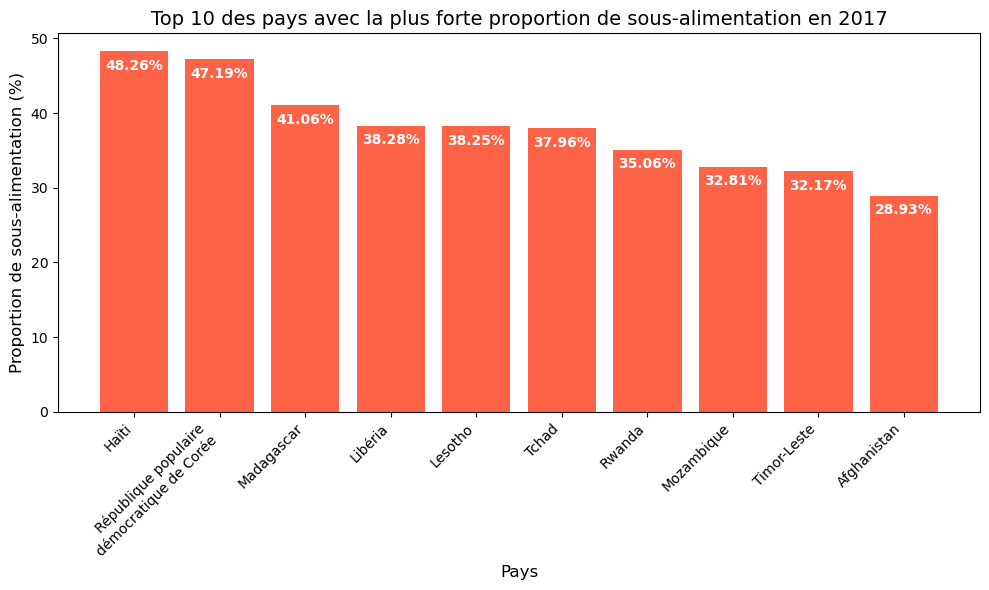

In [188]:
#graphique représentatif des 10 pays avec la proportion de personnes sous-alimentée la plus forte en 2017

import matplotlib.pyplot as plt

# Ajouter des sauts de ligne pour les noms de pays trop longs
pays = top_10_pays_sous_alimentation['Zone'].replace({
    'République populaire démocratique de Corée': 'République populaire\ndémocratique de Corée'
})

proportion_sous_alimentation = top_10_pays_sous_alimentation['Proportion_sous_alimentation']

# Création du graphique en barres verticales
plt.figure(figsize=(10,6))
bars = plt.bar(pays, proportion_sous_alimentation, color='tomato')

# Ajouter des labels aux axes
plt.ylabel("Proportion de sous-alimentation (%)", fontsize=12)
plt.xlabel("Pays", fontsize=12)
plt.title("Top 10 des pays avec la plus forte proportion de sous-alimentation en 2017", fontsize=14)

# Rotation des labels de l'axe x pour améliorer la lisibilité
plt.xticks(rotation=45, ha='right', fontsize=10)

# Ajouter les valeurs sur les barres, à l'intérieur
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1,  # Position du texte
             f'{bar.get_height():.2f}%',  # Affichage de la valeur en pourcentage avec 2 chiffres après la virgule
             ha='center', va='top', color='white', fontweight='bold')

# Ajuster la mise en page pour éviter les chevauchements
plt.tight_layout()

# Affichage du graphique
plt.show()



<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [190]:
#calcul du total de l'aide alimentaire par pays

# Calculer le total de l'aide alimentaire par pays
aide_alimentaire_par_pays = aide_alimentaire.groupby('Zone')['Valeur'].sum().reset_index()

# Renommer la colonne pour plus de clarté
aide_alimentaire_par_pays.rename(columns={'Valeur': 'Total_aide_alimentaire'}, inplace=True)

# Afficher les 5 premières lignes pour vérifier
aide_alimentaire_par_pays.head()

,Zone,Total_aide_alimentaire
0,Afghanistan,185452000
1,Algérie,81114000
2,Angola,5014000
3,Bangladesh,348188000
4,Bhoutan,2666000


In [191]:
#affichage après tri des 10 pays qui ont bénéficié le plus de l'aide alimentaire

# Trier les pays par le total de l'aide alimentaire reçu en ordre décroissant
aide_alimentaire_par_pays_sorted = aide_alimentaire_par_pays.sort_values(by='Total_aide_alimentaire', ascending=False)

# Afficher les 10 pays qui ont reçu le plus d'aide alimentaire
top_10_pays_aide_alimentaire = aide_alimentaire_par_pays_sorted.head(10)

# Affichage des résultats
top_10_pays_aide_alimentaire

# faire un graphique pour montrer cela

,Zone,Total_aide_alimentaire
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


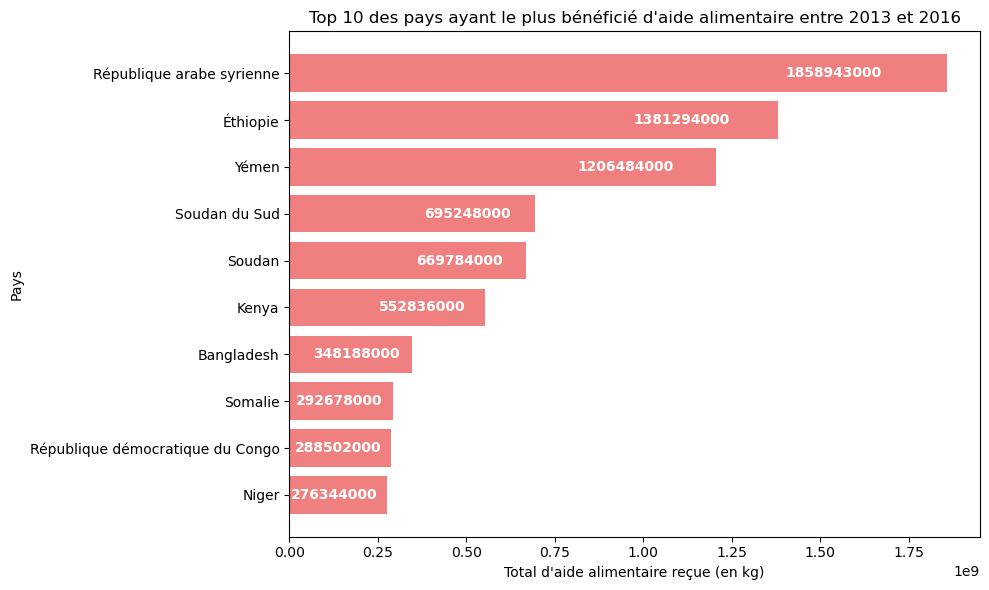

In [192]:
#Graphique de représentation des 10 pays ayant le plus bénéficié de l'aide alimentaire

import matplotlib.pyplot as plt

# Extraire les pays et le total d'aide alimentaire
pays = top_10_pays_aide_alimentaire['Zone']
total_aide = top_10_pays_aide_alimentaire['Total_aide_alimentaire']

# Création du graphique en barres horizontales
plt.figure(figsize=(10,6))
bars = plt.barh(pays, total_aide, color='lightcoral')
plt.xlabel("Total d'aide alimentaire reçue (en kg)")
plt.ylabel("Pays")
plt.title("Top 10 des pays ayant le plus bénéficié d'aide alimentaire entre 2013 et 2016")
plt.gca().invert_yaxis()  # Inverser l'ordre pour que le pays avec le plus d'aide soit en haut

# Ajouter les valeurs sur les barres, à l'intérieur
for bar in bars:
    plt.text(bar.get_width() - (bar.get_width() * 0.1),  # Position horizontale légèrement avant la fin de la barre
             bar.get_y() + bar.get_height()/2,  # Centrer verticalement le texte
             f'{bar.get_width():.0f}',  # Affichage de la valeur arrondie
             va='center', ha='right', color='white', fontweight='bold')  # Alignement à droite et couleur blanche

plt.tight_layout()

# Affichage du graphique
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficié de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [194]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 

# Créer un DataFrame avec les colonnes 'Pays bénéficiaire', 'Année' et 'Valeur'
aide_alimentaire_grouped = aide_alimentaire.groupby(['Zone', 'Année'])['Valeur'].sum().reset_index()

# Afficher les premières lignes pour vérifier
aide_alimentaire_grouped.head()

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000


In [195]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire

# Filtrer les données pour les années entre 2013 et 2016
aide_alimentaire_2013_2016 = aide_alimentaire[aide_alimentaire['Année'].between(2013, 2016)]

# Calculer le total de l'aide alimentaire par pays entre 2013 et 2016
aide_alimentaire_total_pays = aide_alimentaire_2013_2016.groupby('Zone')['Valeur'].sum().reset_index()

# Trier les pays par le total d'aide alimentaire en ordre décroissant
aide_alimentaire_total_pays_sorted = aide_alimentaire_total_pays.sort_values(by='Valeur', ascending=False)

# Sélectionner les 5 pays qui ont le plus bénéficié de l'aide alimentaire
top_5_pays = aide_alimentaire_total_pays_sorted['Zone'].head(5).tolist()

# Afficher la liste des 5 pays
print(top_5_pays)


['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']


In [196]:
#On filtre sur le dataframe avec notre liste

# Filtrer le DataFrame pour ne garder que les données des 5 pays sélectionnés
aide_alimentaire_top_5_pays = aide_alimentaire_grouped[aide_alimentaire_grouped['Zone'].isin(top_5_pays)]

In [200]:
# Affichage des pays avec l'aide alimentaire par année
aide_alimentaire_top_5_pays

,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


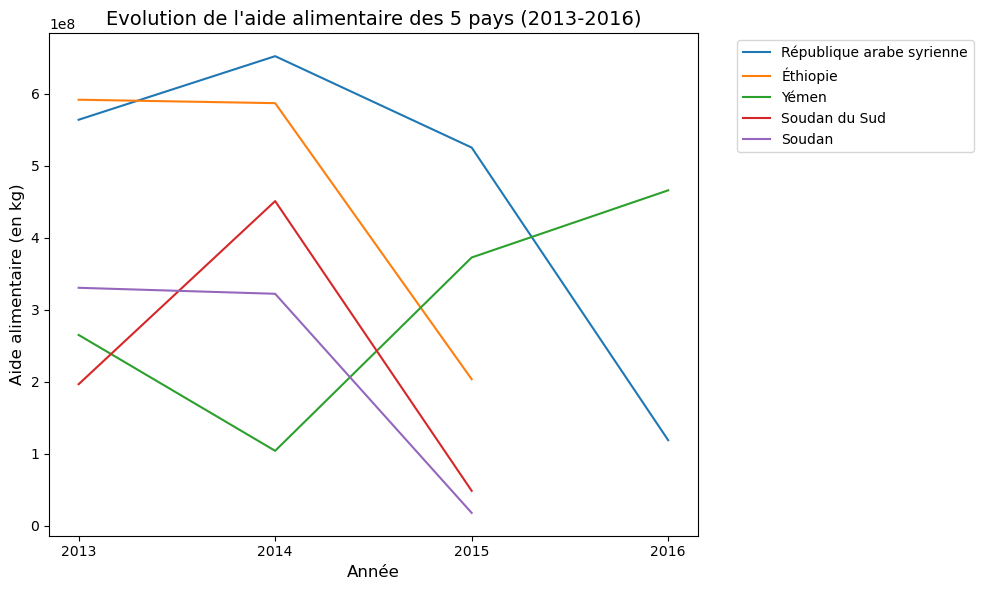

In [201]:
import matplotlib.pyplot as plt

# Tracer un graphique pour l'évolution de l'aide alimentaire des 5 pays
plt.figure(figsize=(10,6))  # Augmenter la taille du graphique pour une meilleure lisibilité

for pays in top_5_pays:
    data_pays = aide_alimentaire_top_5_pays[aide_alimentaire_top_5_pays['Zone'] == pays]
    plt.plot(data_pays['Année'], data_pays['Valeur'], label=pays)

# Ajouter le titre et les labels d'axes
plt.title('Evolution de l\'aide alimentaire des 5 pays (2013-2016)', fontsize=14)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Aide alimentaire (en kg)', fontsize=12)

# Forcer l'affichage des années entières sur l'axe x
plt.xticks([2013, 2014, 2015, 2016])

# Placer la légende à l'extérieur du cadre du graphique
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Ajuster le layout pour éviter les chevauchements
plt.tight_layout()

# Affichage du graphique
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [208]:
#Calcul de la disponibilité en kcal par personne par jour par pays

# Grouper par pays pour calculer la disponibilité totale en Kcal par jour pour chaque pays
dispo_kcal_par_pays = dispo_alimentaire_population.groupby('Zone', as_index=False).agg({
    'dispo_kcal': 'sum',  # Somme de la disponibilité totale en Kcal
    'Population': 'mean'  # Moyenne de la population (car elle est la même pour tous les produits d'un pays)
})

# Calculer la disponibilité en Kcal par personne par jour
dispo_kcal_par_pays['dispo_kcal_par_personne_par_jour'] = dispo_kcal_par_pays['dispo_kcal'] / dispo_kcal_par_pays['Population']

# Afficher les premières lignes pour vérifier
dispo_kcal_par_pays[['Zone', 'Population','dispo_kcal_par_personne_par_jour']].head()


,Zone,Population,dispo_kcal_par_personne_par_jour
0,Afghanistan,36296113.0,2087.0
1,Afrique du Sud,57009756.0,3020.0
2,Albanie,2884169.0,3188.0
3,Algérie,41389189.0,3293.0
4,Allemagne,82658409.0,3503.0


In [211]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 

# Trier les pays par la disponibilité en Kcal par personne par jour en ordre croissant
pays_avec_moins_dispo = dispo_kcal_par_pays.sort_values(by='dispo_kcal_par_personne_par_jour', ascending=True)

# Afficher les 10 pays avec la plus faible disponibilité alimentaire
top_10_pays_moins_dispo = pays_avec_moins_dispo[['Zone', 'Population','dispo_kcal_par_personne_par_jour']].head(10)

# Afficher les résultats
top_10_pays_moins_dispo


,Zone,Population,dispo_kcal_par_personne_par_jour
127,République centrafricaine,4596023.0,1879.0
164,Zambie,16853599.0,1924.0
91,Madagascar,25570512.0,2056.0
0,Afghanistan,36296113.0,2087.0
65,Haïti,10982366.0,2089.0
132,République populaire démocratique de Corée,25429825.0,2093.0
150,Tchad,15016753.0,2109.0
165,Zimbabwe,14236595.0,2113.0
114,Ouganda,41166588.0,2126.0
152,Timor-Leste,1243258.0,2129.0


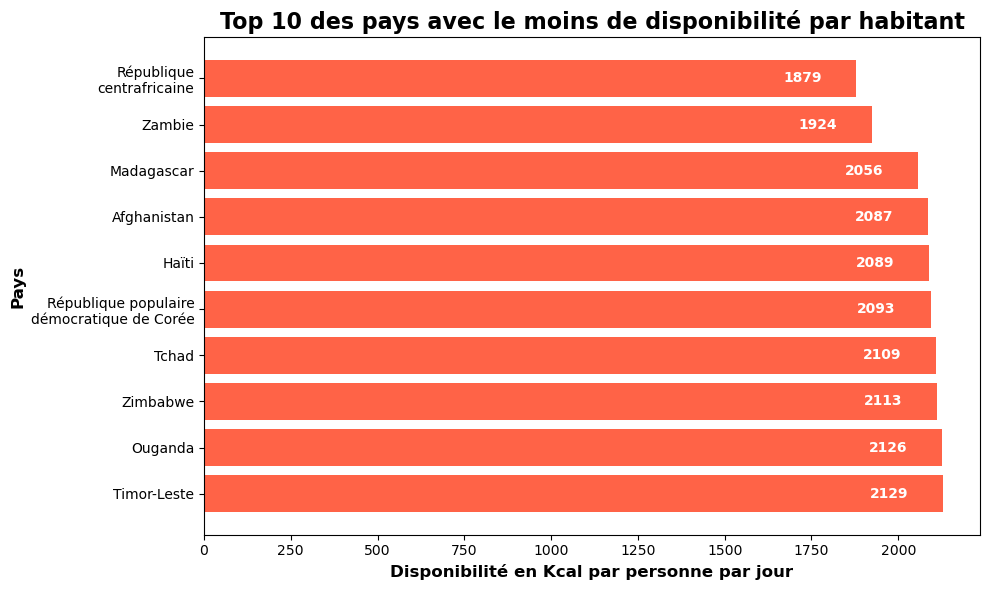

In [213]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne

import matplotlib.pyplot as plt

# Ajouter des sauts de ligne pour les noms de pays trop longs
pays = top_10_pays_moins_dispo['Zone'].replace({
    'République populaire démocratique de Corée': 'République populaire\ndémocratique de Corée',
    'République centrafricaine': 'République\ncentrafricaine'  # Saut de ligne après "République"
})

dispo_kcal_par_personne = top_10_pays_moins_dispo['dispo_kcal_par_personne_par_jour']

# Création du graphique en barres horizontales
plt.figure(figsize=(10,6))
bars = plt.barh(pays, dispo_kcal_par_personne, color='tomato')  # Barres en rouge
plt.xlabel("Disponibilité en Kcal par personne par jour", fontsize=12, fontweight='bold')  # Texte en gras
plt.ylabel("Pays", fontsize=12, fontweight='bold')  # Texte en gras
plt.title("Top 10 des pays avec le moins de disponibilité par habitant", fontsize=16, fontweight='bold')  # Titre plus grand et en gras
plt.gca().invert_yaxis()  # Inverser l'ordre pour que le pays avec la plus petite disponibilité soit en haut

# Ajouter les valeurs sur les barres, à l'intérieur
for bar in bars:
    plt.text(bar.get_width() - 100,  # Position horizontale légèrement avant la fin de la barre
             bar.get_y() + bar.get_height()/2,  # Centrer verticalement le texte
             f'{bar.get_width():.0f}',  # Affichage de la valeur arrondie
             va='center', ha='right', color='white', fontweight='bold')  # Alignement à droite et couleur blanche

plt.tight_layout()

# Affichage du graphique
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [216]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 

# Trier les pays par la disponibilité en Kcal par personne par jour en ordre décroissant
pays_avec_plus_dispo = dispo_kcal_par_pays.sort_values(by='dispo_kcal_par_personne_par_jour', ascending=False)

# Afficher les 10 pays avec la plus forte disponibilité alimentaire
top_10_pays_plus_dispo = pays_avec_plus_dispo[['Zone', 'Population','dispo_kcal_par_personne_par_jour']].head(10)

# Afficher les résultats
top_10_pays_plus_dispo

,Zone,Population,dispo_kcal_par_personne_par_jour
11,Autriche,8819901.0,3770.0
16,Belgique,11419748.0,3737.0
157,Turquie,81116450.0,3708.0
169,États-Unis d'Amérique,325084756.0,3682.0
74,Israël,8243848.0,3610.0
72,Irlande,4753279.0,3602.0
75,Italie,60673701.0,3578.0
89,Luxembourg,591910.0,3540.0
166,Égypte,96442591.0,3518.0
4,Allemagne,82658409.0,3503.0


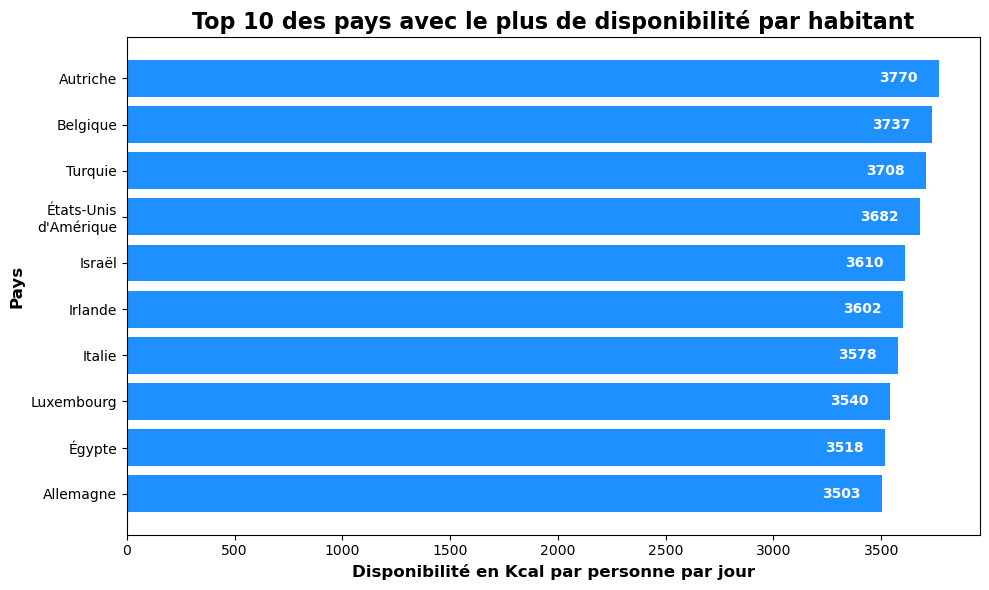

In [218]:
# Code pour le graphique avec les 10 pays ayant la plus grande disponibilité alimentaire par habitant (barres bleues) :

import matplotlib.pyplot as plt

# Ajouter des sauts de ligne pour les noms de pays trop longs
pays = top_10_pays_plus_dispo['Zone'].replace({
    'États-Unis d\'Amérique': 'États-Unis\nd\'Amérique'  # Saut de ligne après "États-Unis"
})

dispo_kcal_par_personne = top_10_pays_plus_dispo['dispo_kcal_par_personne_par_jour']

# Création du graphique en barres horizontales
plt.figure(figsize=(10,6))
bars = plt.barh(pays, dispo_kcal_par_personne, color='dodgerblue')  # Barres en bleu
plt.xlabel("Disponibilité en Kcal par personne par jour", fontsize=12, fontweight='bold')  # Texte en gras
plt.ylabel("Pays", fontsize=12, fontweight='bold')  # Texte en gras
plt.title("Top 10 des pays avec le plus de disponibilité par habitant", fontsize=16, fontweight='bold')  # Titre plus grand et en gras
plt.gca().invert_yaxis()  # Inverser l'ordre pour que le pays avec la plus petite disponibilité soit en haut

# Ajouter les valeurs sur les barres, à l'intérieur
for bar in bars:
    plt.text(bar.get_width() - 100,  # Position horizontale légèrement avant la fin de la barre
             bar.get_y() + bar.get_height()/2,  # Centrer verticalement le texte
             f'{bar.get_width():.0f}',  # Affichage de la valeur arrondie
             va='center', ha='right', color='white', fontweight='bold')  # Alignement à droite et couleur blanche

plt.tight_layout()

# Affichage du graphique
plt.show()



<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [221]:
#création d'un dataframe avec uniquement la Thaïlande 

# Filtrer le DataFrame pour ne garder que les données de la Thaïlande
df_thailande = dispo_alimentaire_population[dispo_alimentaire_population['Zone'] == 'Thaïlande']

# Afficher les premières lignes pour vérifier
df_thailande.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal
13570,Thaïlande,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000000.0,5.000000e+06,33000000.0,75000000.0,0.0,4.500000e+07,0.0,0.0,0.0,69209810.0,207629430.0
13571,Thaïlande,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000000.0,6.000000e+06,2000000.0,6000000.0,0.0,1.200000e+07,0.0,2000000.0,0.0,69209810.0,0.0
13572,Thaïlande,"Alcool, non Comestible",vegetale,0.0,358000000.0,0.0,0.00,0.00,0.00,358000000.0,1.100000e+08,21000000.0,0.0,0.0,4.470000e+08,0.0,0.0,0.0,69209810.0,0.0
13573,Thaïlande,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000000.0,7.000000e+06,19000000.0,12000000.0,0.0,0.000000e+00,0.0,0.0,0.0,69209810.0,138419620.0
13574,Thaïlande,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000000.0,1.449000e+09,9000000.0,671000000.0,110000000.0,2.209000e+09,0.0,0.0,13000000.0,69209810.0,692098100.0


In [223]:
#Calcul de la sous nutrition en Thaïlande

# Extraire les données de sous-nutrition pour la Thaïlande
sous_nutrition_thailande = population_sous_nutrition[population_sous_nutrition['Zone'] == 'Thaïlande']

# Calculer la sous-nutrition totale en Thaïlande (en nombre de personnes)
sous_nutrition_thailande_total = sous_nutrition_thailande['sous_nutrition'].sum()

# Afficher le résultat
print(f"La population en sous-nutrition en Thaïlande en 2017 était de {int(sous_nutrition_thailande_total):,} personnes, ce qui représente {sous_nutrition_thailande['Proportion_sous_alimentation'].sum():.2f} % de la population totale")


La population en sous-nutrition en Thaïlande en 2017 était de 6,200,000 personnes, ce qui représente 8.96 % de la population totale


In [225]:
sous_nutrition_thailande.head()

,Zone,Année_x,Population,Année_y,sous_nutrition,Proportion_sous_alimentation
185,Thaïlande,2017,69209810.0,2016-2018,6200000.0,8.958268


In [227]:
# On calcule la proportion de manioc exporté en fonction par rapport à la production

# Filtrer les données pour ne garder que les informations sur le Manioc en Thaïlande
df_thailande_manioc = df_thailande[df_thailande['Produit'] == 'Manioc']

# Calculer la proportion exportée (Exportations / Production)
proportion_exportee_manioc = (df_thailande_manioc['Exportations - Quantité'].sum() / df_thailande_manioc['Production'].sum())*100

# Afficher le résultat
print(f"La proportion de manioc exportée par la Thaïlande est de {proportion_exportee_manioc:.2f} % de la production intérieure.")


La proportion de manioc exportée par la Thaïlande est de 83.41 % de la production intérieure.


In [229]:
# Ajout du calcul de la disponibilité par habitant en Thaïlande

# Calculer la disponibilité totale en Kcal par jour pour la Thaïlande
dispo_kcal_total_thailande = df_thailande['dispo_kcal'].sum()

# Calculer la population totale de la Thaïlande
population_thailande = df_thailande['Population'].mean()

# Calculer la disponibilité en Kcal par personne par jour
dispo_kcal_par_habitant_thailande = dispo_kcal_total_thailande / population_thailande

# Afficher la disponibilité par habitant
print(f"La disponibilité par habitant en Thaïlande est de {dispo_kcal_par_habitant_thailande:.2f} Kcal par jour.")


La disponibilité par habitant en Thaïlande est de 2785.00 Kcal par jour.


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [232]:
#Rajouter en dessous toutes les analyses complémtaires suite à la demande de mélanie :
#"et toutes les infos que tu trouverais utiles pour mettre en relief les pays qui semblent être 
#le plus en difficulté au niveau alimentaire"

In [234]:
# Première analyse complémentaire : Analyse de l'impact des aides alimentaires internationales (avec corrélation)

In [264]:
# Calcul de l'évolution de la sous-alimentation dans les pays ayant reçu le plus d'aide
aide_sous_nutrition = population_sous_nutrition.merge(
    aide_alimentaire_par_pays, on='Zone', how='left'
)

# Calculer la corrélation entre aide reçue et sous-alimentation
correlation_aide_sous_nutrition = aide_sous_nutrition[['Total_aide_alimentaire', 'sous_nutrition']].corr()


In [266]:
# Afficher la corrélation
print(f"Corrélation entre l'aide alimentaire et la sous-nutrition: {correlation_aide_sous_nutrition.iloc[0,1]:.2f}")


Corrélation entre l'aide alimentaire et la sous-nutrition: 0.25


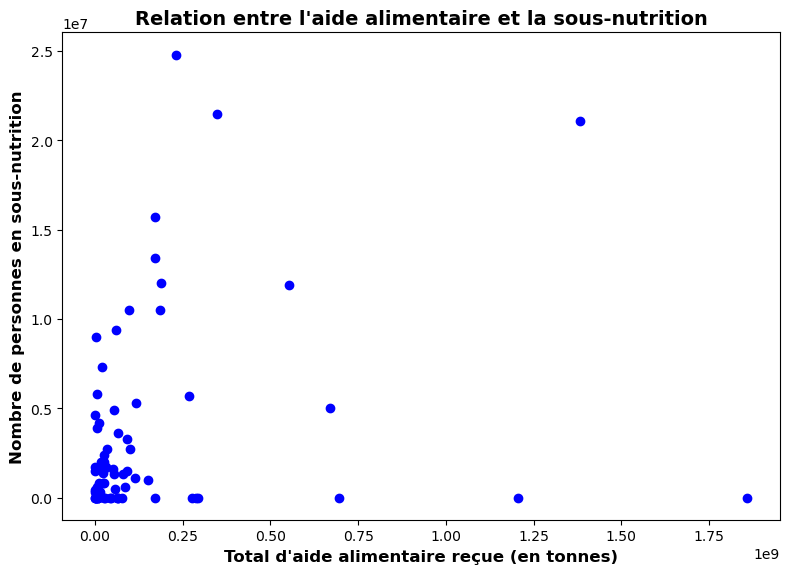

In [244]:
#graphique de l’impact des aides alimentaires internationales:

import matplotlib.pyplot as plt

# Création d'un nuage de points pour visualiser la relation entre aide alimentaire et sous-nutrition
plt.figure(figsize=(8,6))
plt.scatter(aide_sous_nutrition['Total_aide_alimentaire'], aide_sous_nutrition['sous_nutrition'], color='blue')

# Ajouter des labels et un titre
plt.xlabel("Total d'aide alimentaire reçue (en tonnes)", fontsize=12, fontweight='bold')
plt.ylabel("Nombre de personnes en sous-nutrition", fontsize=12, fontweight='bold')
plt.title("Relation entre l'aide alimentaire et la sous-nutrition", fontsize=14, fontweight='bold')

# Afficher le graphique
plt.tight_layout()
plt.show()


In [245]:
# Seconde analyse complémentaire : évolution de la sous-nutrition dans les pays recevant de l'aide alimentaire

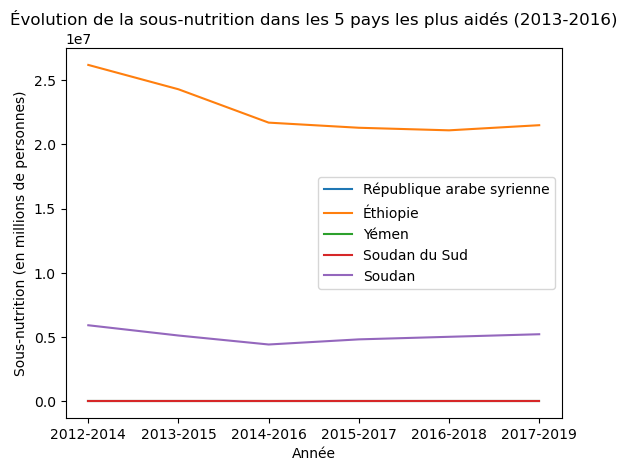

In [248]:
# Filtrer le DataFrame pour les 5 pays ayant reçu le plus d'aide alimentaire
top_5_pays = ['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

# Filtrer la sous-nutrition pour ces pays
sous_nutrition_top_5_pays = sous_nutrition[sous_nutrition['Zone'].isin(top_5_pays)]

# Affichage de l'évolution de la sous-nutrition pour chaque pays sur les années disponibles
import matplotlib.pyplot as plt

for pays in top_5_pays:
    data_pays = sous_nutrition_top_5_pays[sous_nutrition_top_5_pays['Zone'] == pays]
    plt.plot(data_pays['Année'], data_pays['sous_nutrition'], label=pays)

plt.title('Évolution de la sous-nutrition dans les 5 pays les plus aidés (2013-2016)')
plt.xlabel('Année')
plt.ylabel('Sous-nutrition (en millions de personnes)')
plt.legend()
plt.show()


In [250]:
print(sous_nutrition_top_5_pays.head(20))  # Afficher les 20 premières lignes pour voir les valeurs disponibles


                           Zone      Année  sous_nutrition
366                    Éthiopie  2012-2014      26200000.0
367                    Éthiopie  2013-2015      24300000.0
368                    Éthiopie  2014-2016      21700000.0
369                    Éthiopie  2015-2017      21300000.0
370                    Éthiopie  2016-2018      21100000.0
371                    Éthiopie  2017-2019      21500000.0
900   République arabe syrienne  2012-2014             0.0
901   République arabe syrienne  2013-2015             0.0
902   République arabe syrienne  2014-2016             0.0
903   République arabe syrienne  2015-2017             0.0
904   République arabe syrienne  2016-2018             0.0
905   République arabe syrienne  2017-2019             0.0
1056                     Soudan  2012-2014       5900000.0
1057                     Soudan  2013-2015       5100000.0
1058                     Soudan  2014-2016       4400000.0
1059                     Soudan  2015-2017       4800000